<a href="https://colab.research.google.com/github/Zaka123456/MRP/blob/main/01_RF_V1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# === Install Required Libraries ===
!pip install -q scikit-learn

# === Imports ===
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

# === Load and Aggregate Dataset ===
file_path = "/content/drive/MyDrive/MRP/Current/Deliverables/Methodology_&_Experiments/Report/Coding/Data_files/Final_Selected_Features_new.csv"
df = pd.read_csv(file_path, parse_dates=["date_only"])
df = df.sort_values("date_only")



In [ ]:
df

,Sales,Order Profit Per Order,Order Item Quantity,Order Item Discount,Order Item Discount Rate,Order Item Profit Ratio,Product Card Id,Type_DEBIT,Delivery Status_Late delivery,Market_LATAM,...,tempmax,humidity,solarradiation,Sales_lag_1,temp_lag_1,temp_lag_7,temp_lag_30,latitude,longitude,date_only
116881,499.850002,97.550004,15,11.9975,0.0925,0.1425,3,4,4,4,...,84.6,79.8,195.5,499.850002,79.6,NaN,NaN,18.262,-66.371,2015-01-01
66258,1129.860039,390.089995,10,28.5580,0.1360,0.3460,4,5,5,5,...,84.6,79.8,195.5,1129.860039,79.6,79.6,NaN,18.234,-66.371,2015-01-01
13915,299.980011,66.419998,1,54.0000,0.1800,0.2700,1,0,0,1,...,84.6,79.7,195.5,NaN,NaN,NaN,NaN,18.208,-66.371,2015-01-01
13916,299.980011,66.419998,1,54.0000,0.1800,0.2700,1,0,0,1,...,84.6,79.7,195.5,299.980011,79.6,NaN,NaN,18.208,-66.371,2015-01-01
13917,299.980011,66.419998,1,54.0000,0.1800,0.2700,1,0,0,1,...,84.6,79.7,195.5,299.980011,79.6,NaN,NaN,18.208,-66.371,2015-01-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
146572,659.890015,55.150000,8,14.5725,0.0875,0.1000,4,0,0,0,...,83.7,81.6,192.5,659.890015,76.2,76.2,80.2,18.280,-66.371,2016-12-31
146573,659.890015,55.150000,8,14.5725,0.0875,0.1000,4,0,0,0,...,83.7,81.6,192.5,659.890015,76.2,76.2,80.2,18.280,-66.371,2016-12-31
146574,659.890015,55.150000,8,14.5725,0.0875,0.1000,4,0,0,0,...,83.7,81.6,192.5,659.890015,76.2,76.2,80.2,18.280,-66.371,2016-12-31
93660,654.899998,-346.129984,9,23.5225,0.1000,-0.1300,4,4,4,0,...,83.8,81.1,187.9,654.899998,77.2,78.4,80.4,18.248,-66.025,2016-12-31


In [ ]:
df.shape

(211898, 24)

In [ ]:
df.isnull().sum()

,0
Sales,0
Order Profit Per Order,0
Order Item Quantity,0
Order Item Discount,0
Order Item Discount Rate,0
Order Item Profit Ratio,0
Product Card Id,0
Type_DEBIT,0
Delivery Status_Late delivery,0
Market_LATAM,0


In [ ]:
# === Fill Missing Values ===
weather_cols = ['tempmax', 'humidity', 'solarradiation']
lag_cols = ['Sales_lag_1', 'temp_lag_1', 'temp_lag_7', 'temp_lag_30']

for col in weather_cols + lag_cols:
    df[col] = df[col].fillna(method='ffill').fillna(method='bfill')

display(df.isnull().sum())

/tmp/ipython-input-1673397667.py:6: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[col] = df[col].fillna(method='ffill').fillna(method='bfill')


,0
Sales,0
Order Profit Per Order,0
Order Item Quantity,0
Order Item Discount,0
Order Item Discount Rate,0
Order Item Profit Ratio,0
Product Card Id,0
Type_DEBIT,0
Delivery Status_Late delivery,0
Market_LATAM,0



=== Test Set Evaluation ===
MAE   : 50.46
RMSE  : 90.02
sMAPE : 8.36%
R²    : 0.929

3-Fold CV R² Scores: [0.90457451 0.91817209 0.911952  ]
Mean CV R²: 0.912


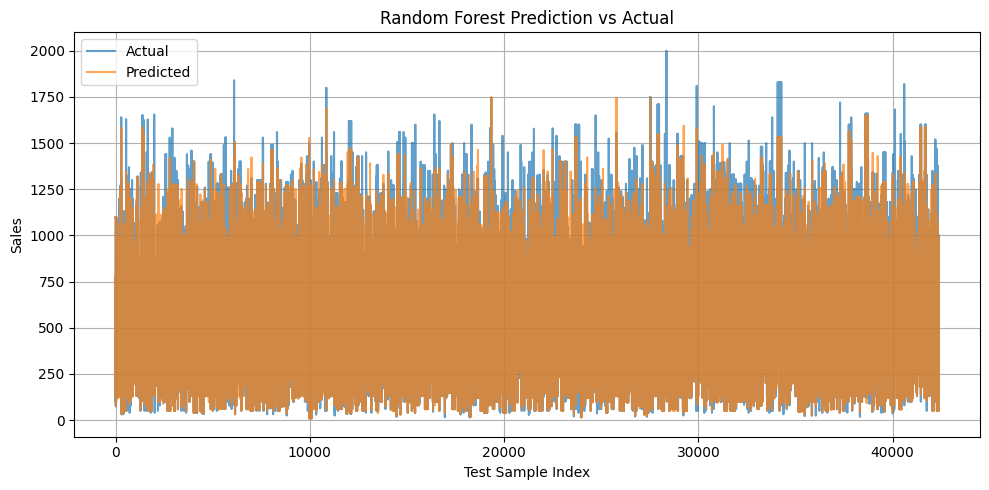

In [ ]:
# === Feature/Target Split ===
target = "Sales"
features = df.drop(columns=["Sales", "date_only", "latitude", "longitude"])
X = features.select_dtypes(include=[np.number])
y = df[target]

# === Normalize Features ===
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# === Train/Test Split ===
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, shuffle=False)

# === Fit Random Forest ===
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# === Predict and Evaluate ===
y_pred = rf.predict(X_test)

# Metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

def smape(actual, forecast):
    denominator = (np.abs(actual) + np.abs(forecast)) / 2
    diff = np.abs(actual - forecast)
    return np.mean(np.where(denominator == 0, 0, diff / denominator)) * 100

s_mape = smape(y_test.values, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n=== Test Set Evaluation ===")
print(f"MAE   : {mae:.2f}")
print(f"RMSE  : {rmse:.2f}")
print(f"sMAPE : {s_mape:.2f}%")
print(f"R²    : {r2:.3f}")

# === Cross-Validation (3-Fold) on Training Set ===
cv_scores = cross_val_score(rf, X_train, y_train, cv=3, scoring='r2')
print(f"\n3-Fold CV R² Scores: {cv_scores}")
print(f"Mean CV R²: {np.mean(cv_scores):.3f}")

# === Optional: Plot Predicted vs Actual ===
plt.figure(figsize=(10, 5))
plt.plot(y_test.values, label="Actual", alpha=0.7)
plt.plot(y_pred, label="Predicted", alpha=0.7)
plt.title("Random Forest Prediction vs Actual")
plt.xlabel("Test Sample Index")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/MRP/Current/Deliverables/Methodology_&_Experiments/Report/Coding/Data_files/Plots/rf_prediction_vs_actual.png")
plt.show()